# Step 2: Initial Look
## Headline Goal
The Acme Armadillos have seen declining attendance since 2021, even as ticket revenue has grown. This notebook takes a first broad look at the ticketing data through overall trends, breakdowns by customer segment (Full Season, Partial Season, Group, Single Game), and cuts by day of week, month, and no-show behavior to identify where the decline is concentrated and prioritize what to dig into next.

## Contents
1. **Setup** — Imports & Visualization Standards, Load in Data
2. **YoY Trends (High Level)** — Total Tickets, Total Revenue, Average Ticket Price by year, both blended and broken out by segment
3. **Ticketing by Segments** — Cumulative tickets & revenue by segment
4. **Trends within Day/Month of Games** — Avg tickets & price by Day of Week and Month, for each of the four segments
5. **No-Show Rates** — No-show rate and total missing attendance, by Overall/Day of Week/Month/Day or Night
6. **Final Initial Thoughts** — Summary of key findings and prioritized next steps for deep-dive analysis

### - Establish Visualization Standards

In [1]:
# ============================================================
# Imports & Visualization Standards
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Standard color palette (order: Blue, Red, Teal, Yellow)
PALETTE = ['#0000a2', '#bc272d', '#50ad9f', '#e9c716']

# Standard figure size for all charts
FIGSIZE = (22, 8.5)

# Axis formatters
def thousands_formatter(x, pos):
    return f'{x/1000:,.0f}K'

def millions_formatter(x, pos):
    return f'${x/1_000_000:,.1f}M'

def millions_plain_formatter(x, pos):
    return f'{x/1_000_000:,.1f}M'

# Standard label styling
TITLE_STYLE = {'fontsize': 18, 'fontweight': 'bold'}
LABEL_STYLE = {'fontsize': 16, 'fontweight': 'bold'}

# Shared constants used across multiple analysis cells
YEARS = [2021, 2022, 2023]
YEAR_COLORS = dict(zip(YEARS, PALETTE))
DOW_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
MONTH_ORDER = ['April', 'May', 'June', 'July', 'August', 'September']
DAYNIGHT_ORDER = ['Day Game', 'Night Game']
BAR_WIDTH = 0.25

### - Load in Data

In [2]:
full = pd.read_csv('../step_01_clean_data/clean_data.csv', parse_dates=['Game Date'])

print(f"Loaded: {full.shape[0]} rows, {full.shape[1]} columns")
full.head()

Loaded: 243 rows, 26 columns


,Home Game #,Game Date,Year,Month,Day of Week,Weekend / Weekday,Game Time,Day/Night,Full Season Tickets (#),Full Season Revenue ($),...,Group Avg Price ($),Single Game Tickets (#),Single Game Revenue ($),Single Game Avg Price ($),No-Show Rate,Total Tickets (#),Actual Attendance (#),Total Revenue ($),Average Ticket Price ($),Is First Month
0,1,2021-04-01,2021,April,Thursday,Weekday,13:10:00,Day Game,9361,417794.04,...,46.83,16916,1013906.60,59.94,0.1420,36688,31478,1870492.51,50.98,True
1,2,2021-04-02,2021,April,Friday,Weekend,19:10:00,Night Game,9374,415278.62,...,25.93,9023,272800.32,30.23,0.1752,24520,20224,852818.98,34.78,True
2,3,2021-04-03,2021,April,Saturday,Weekend,18:10:00,Night Game,9398,414149.54,...,30.51,10411,373733.78,35.90,0.1643,28927,24174,1057199.15,36.55,True
3,4,2021-04-04,2021,April,Sunday,Weekend,13:10:00,Day Game,9374,415431.58,...,30.16,12149,411154.96,33.84,0.1609,28561,23966,1057229.43,37.02,True
4,5,2021-04-09,2021,April,Friday,Weekend,19:10:00,Night Game,9376,416211.65,...,30.28,10282,408009.37,39.68,0.1570,29910,25214,1141873.37,38.18,True


# Get a high-level understanding of the YoY trends

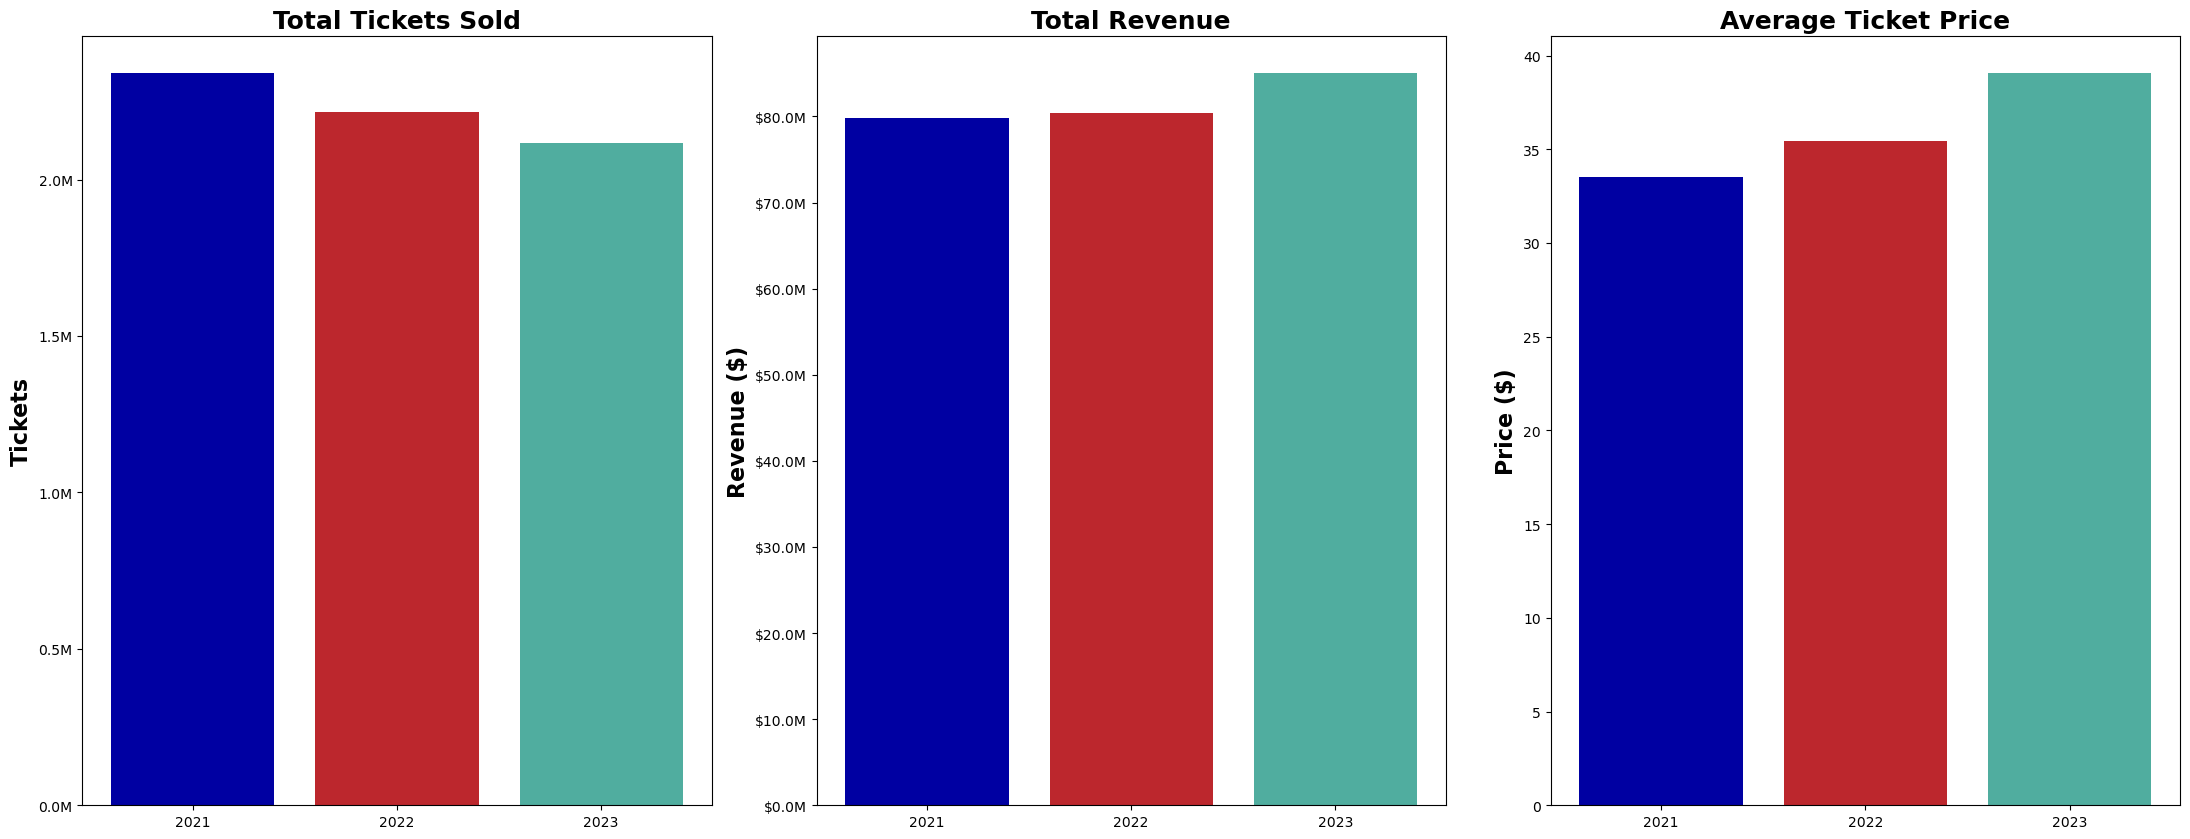

In [3]:
# Aggregate by year
season_summary = full.groupby('Year').agg(
    Total_Tickets=('Total Tickets (#)', 'sum'),
    Total_Revenue=('Total Revenue ($)', 'sum'),
    Avg_Ticket_Price=('Average Ticket Price ($)', 'mean')
).round(2)

years = season_summary.index.astype(str)
colors = PALETTE[:len(years)]

fig, axes = plt.subplots(1, 3, figsize=FIGSIZE)

# Left: Total Tickets Sold
axes[0].bar(years, season_summary['Total_Tickets'], color=colors)
axes[0].set_title('Total Tickets Sold', **TITLE_STYLE)
axes[0].set_ylabel('Tickets', **LABEL_STYLE)
axes[0].yaxis.set_major_formatter(FuncFormatter(millions_plain_formatter))

# Middle: Total Revenue
axes[1].bar(years, season_summary['Total_Revenue'], color=colors)
axes[1].set_title('Total Revenue', **TITLE_STYLE)
axes[1].set_ylabel('Revenue ($)', **LABEL_STYLE)
axes[1].yaxis.set_major_formatter(FuncFormatter(millions_formatter))

# Right: Average Ticket Price
axes[2].bar(years, season_summary['Avg_Ticket_Price'], color=colors)
axes[2].set_title('Average Ticket Price', **TITLE_STYLE)
axes[2].set_ylabel('Price ($)', **LABEL_STYLE)

plt.tight_layout()
plt.show()

**Notes/Thoughts:**
- Total tickets sold declined every year from 2021→2023, while total revenue increased, which is being driven by increasing Avg Ticket Prices.
- This tells us price increases are masking a real attendance/volume problem.
- Next: Need to dig into where the ticket decline is concentrated.

# Understanding ticketing by group

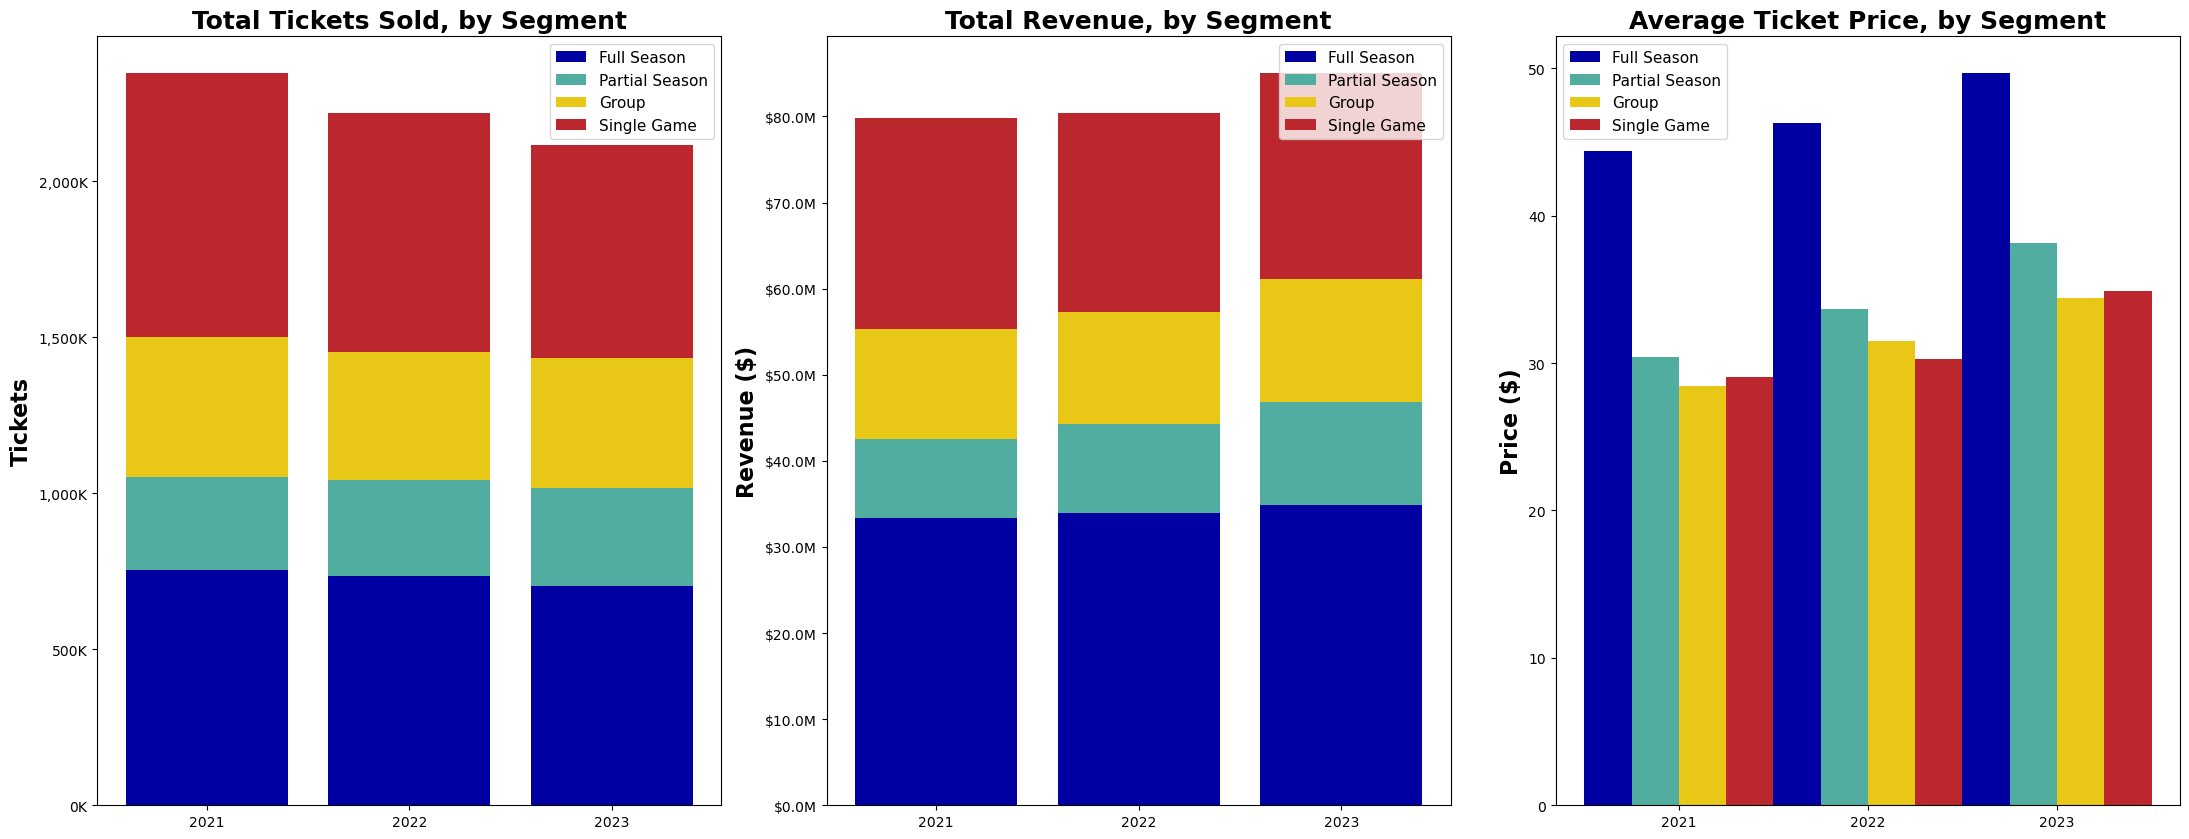

In [4]:
fs_tix = full.groupby('Year')['Full Season Tickets (#)'].sum()
ps_tix = full.groupby('Year')['Partial Season Tickets (#)'].sum()
grp_tix = full.groupby('Year')['Group Tickets (#)'].sum()
sg_tix = full.groupby('Year')['Single Game Tickets (#)'].sum()

fs_rev = full.groupby('Year')['Full Season Revenue ($)'].sum()
ps_rev = full.groupby('Year')['Partial Season Revenue ($)'].sum()
grp_rev = full.groupby('Year')['Group Revenue ($)'].sum()
sg_rev = full.groupby('Year')['Single Game Revenue ($)'].sum()

fs_price = fs_rev/fs_tix
ps_price = ps_rev/ps_tix
grp_price = grp_rev/grp_tix
sg_price = sg_rev/sg_tix

years = fs_tix.index.astype(str)

fig, axes = plt.subplots(1, 3, figsize=FIGSIZE)

# LEFT: Total Tickets Sold, stacked by segment
axes[0].bar(years, fs_tix, color=PALETTE[0], label='Full Season')
axes[0].bar(years, ps_tix, bottom=fs_tix, color=PALETTE[2], label='Partial Season')
axes[0].bar(years, grp_tix, bottom=fs_tix+ps_tix, color=PALETTE[3], label='Group')
axes[0].bar(years, sg_tix, bottom=fs_tix+ps_tix+grp_tix, color=PALETTE[1], label='Single Game')
axes[0].set_title('Total Tickets Sold, by Segment', **TITLE_STYLE)
axes[0].set_ylabel('Tickets', **LABEL_STYLE)
axes[0].yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
axes[0].legend(fontsize=11)

# MIDDLE: Total Revenue, stacked by segment
axes[1].bar(years, fs_rev, color=PALETTE[0], label='Full Season')
axes[1].bar(years, ps_rev, bottom=fs_rev, color=PALETTE[2], label='Partial Season')
axes[1].bar(years, grp_rev, bottom=fs_rev+ps_rev, color=PALETTE[3], label='Group')
axes[1].bar(years, sg_rev, bottom=fs_rev+ps_rev+grp_rev, color=PALETTE[1], label='Single Game')
axes[1].set_title('Total Revenue, by Segment', **TITLE_STYLE)
axes[1].set_ylabel('Revenue ($)', **LABEL_STYLE)
axes[1].yaxis.set_major_formatter(FuncFormatter(millions_formatter))
axes[1].legend(fontsize=11)

# RIGHT: Average Ticket Price, grouped by segment
x = range(len(years))
axes[2].bar([xi-1.5*BAR_WIDTH for xi in x], fs_price, width=BAR_WIDTH, color=PALETTE[0], label='Full Season')
axes[2].bar([xi-0.5*BAR_WIDTH for xi in x], ps_price, width=BAR_WIDTH, color=PALETTE[2], label='Partial Season')
axes[2].bar([xi+0.5*BAR_WIDTH for xi in x], grp_price, width=BAR_WIDTH, color=PALETTE[3], label='Group')
axes[2].bar([xi+1.5*BAR_WIDTH for xi in x], sg_price, width=BAR_WIDTH, color=PALETTE[1], label='Single Game')
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(years)
axes[2].set_title('Average Ticket Price, by Segment', **TITLE_STYLE)
axes[2].set_ylabel('Price ($)', **LABEL_STYLE)
axes[2].legend(fontsize=11)

plt.tight_layout()
plt.show()

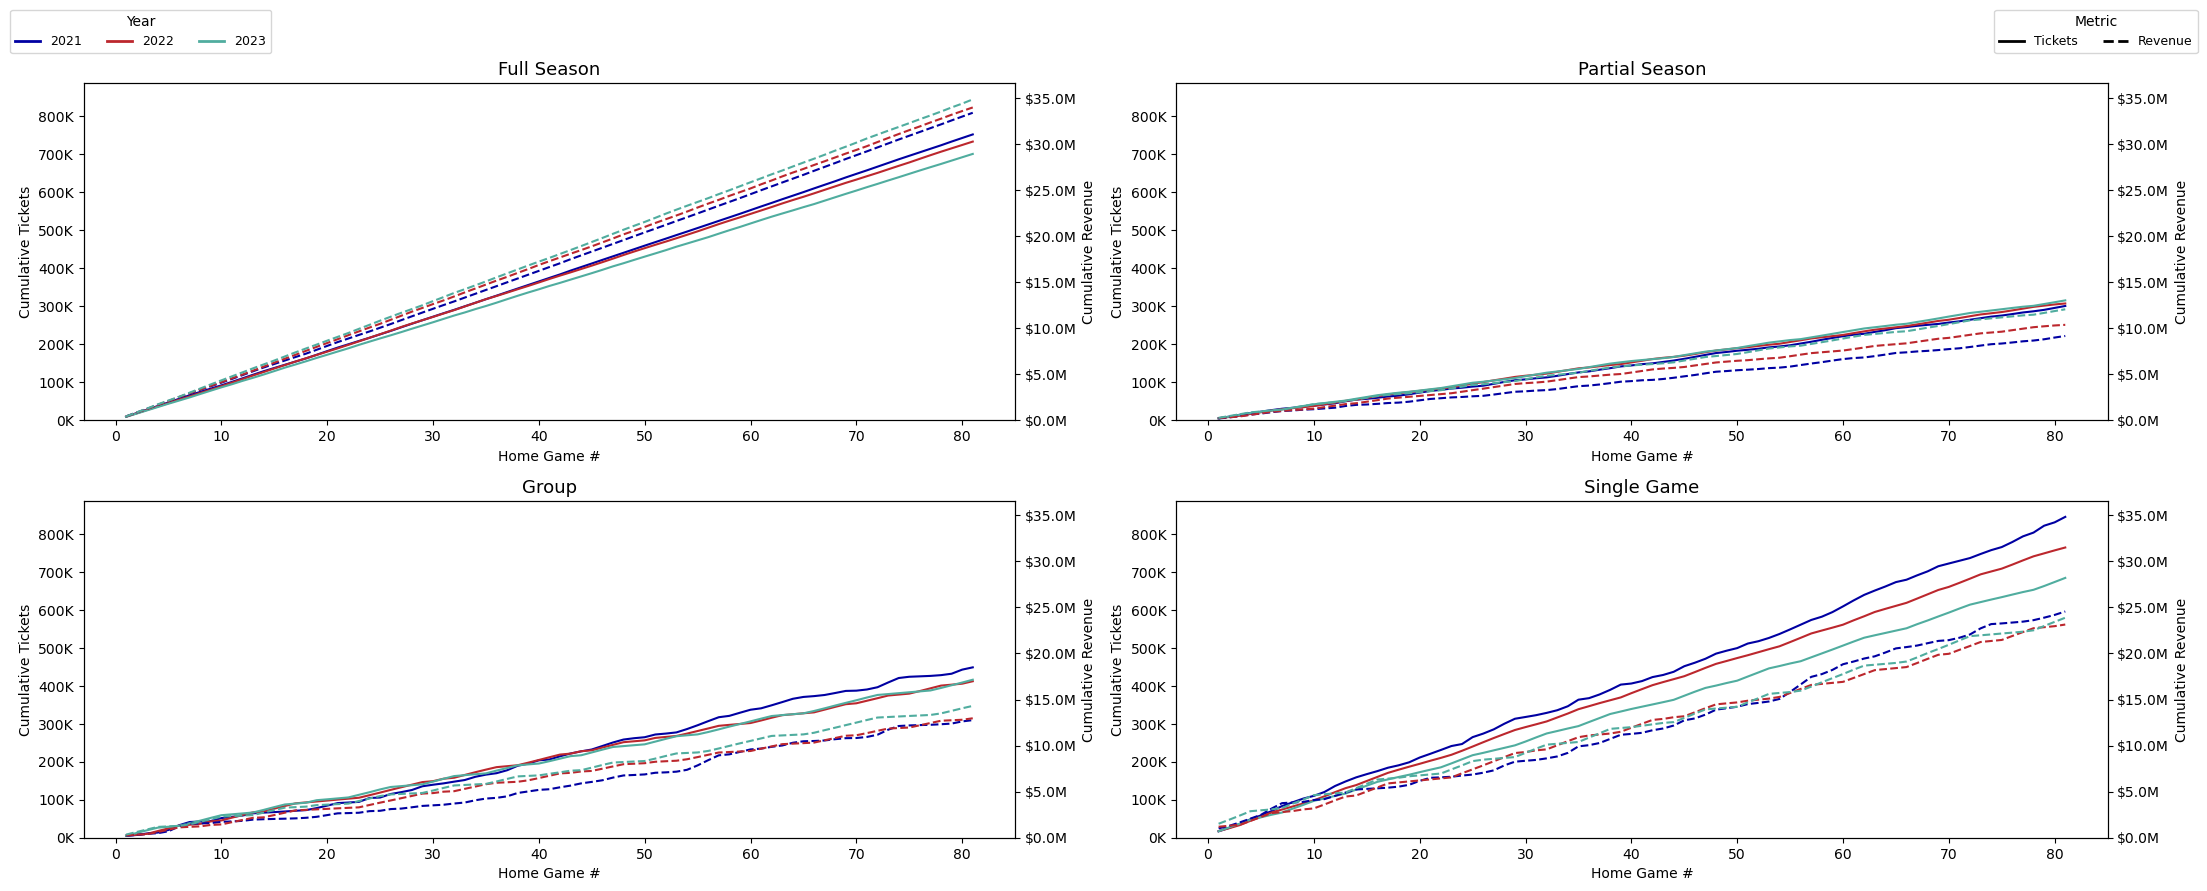

In [5]:
segments = {
    'Full Season': ('Full Season Tickets (#)', 'Full Season Revenue ($)'),
    'Partial Season': ('Partial Season Tickets (#)', 'Partial Season Revenue ($)'),
    'Group': ('Group Tickets (#)', 'Group Revenue ($)'),
    'Single Game': ('Single Game Tickets (#)', 'Single Game Revenue ($)')
}

# First pass: compute max cumulative values across all segments/years, so every panel shares the same scale
max_tickets = 0
max_revenue = 0
for seg_name, (ticket_col, revenue_col) in segments.items():
    for year in YEAR_COLORS:
        year_data = full[full['Year'] == year].sort_values('Home Game #')
        max_tickets = max(max_tickets, year_data[ticket_col].cumsum().max())
        max_revenue = max(max_revenue, year_data[revenue_col].cumsum().max())

fig, axes = plt.subplots(2, 2, figsize=FIGSIZE)
axes = axes.flatten()

for ax, (seg_name, (ticket_col, revenue_col)) in zip(axes, segments.items()):
    ax2 = ax.twinx()
    for year, color in YEAR_COLORS.items():
        year_data = full[full['Year'] == year].sort_values('Home Game #')
        ax.plot(year_data['Home Game #'], year_data[ticket_col].cumsum(), color=color, linestyle='solid')
        ax2.plot(year_data['Home Game #'], year_data[revenue_col].cumsum(), color=color, linestyle='dashed')

    ax.set_title(seg_name, fontsize=13)
    ax.set_xlabel('Home Game #')
    ax.set_ylabel('Cumulative Tickets')
    ax.set_ylim(0, max_tickets * 1.05)
    ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

    ax2.set_ylabel('Cumulative Revenue')
    ax2.set_ylim(0, max_revenue * 1.05)
    ax2.yaxis.set_major_formatter(FuncFormatter(millions_formatter))

# Two clean legends: Year (color), Metric (line style)
year_handles = [plt.Line2D([0], [0], color=color, lw=2) for color in YEAR_COLORS.values()]
metric_handles = [plt.Line2D([0], [0], color='black', linestyle=ls, lw=2) for ls in ['solid', 'dashed']]

fig.legend(year_handles, [str(y) for y in YEAR_COLORS.keys()], title='Year',
           loc='upper left', bbox_to_anchor=(0.0, 1.05), ncol=3, fontsize=9)
fig.legend(metric_handles, ['Tickets', 'Revenue'], title='Metric',
           loc='upper right', bbox_to_anchor=(1.0, 1.05), ncol=2, fontsize=9)

plt.tight_layout()
plt.show()

**Notes/Thoughts:**
- Single Game is the highest reduction YoY in total tickets. This is the key driver in ticket reduction
- Single-game and Full-Season tickets are the highest percentage of total tickets and revenue
- Single Game revenue doesn't separate by year nearly as much as ticket volume does. Prices rose enough to mask a lot of the ticket decline here, same story as the headline chart
- The Partial Season tickets seem pretty consistent YoY, but revenue continues to increase (these customers seem the most reliable)
- Group's decline shows up differently. 2021 tracks right with 2022/2023 through about half the season, then pulls ahead in the back half. Something changed in 2021 specifically that didn't repeat which may worth digging into
- Group revenue also stays tight across years even though ticket volume clearly splits 2021 vs 2022/2023. Looks like Group prices rose too and offset some of that decline

# Looking for trends within the Day/Month of games

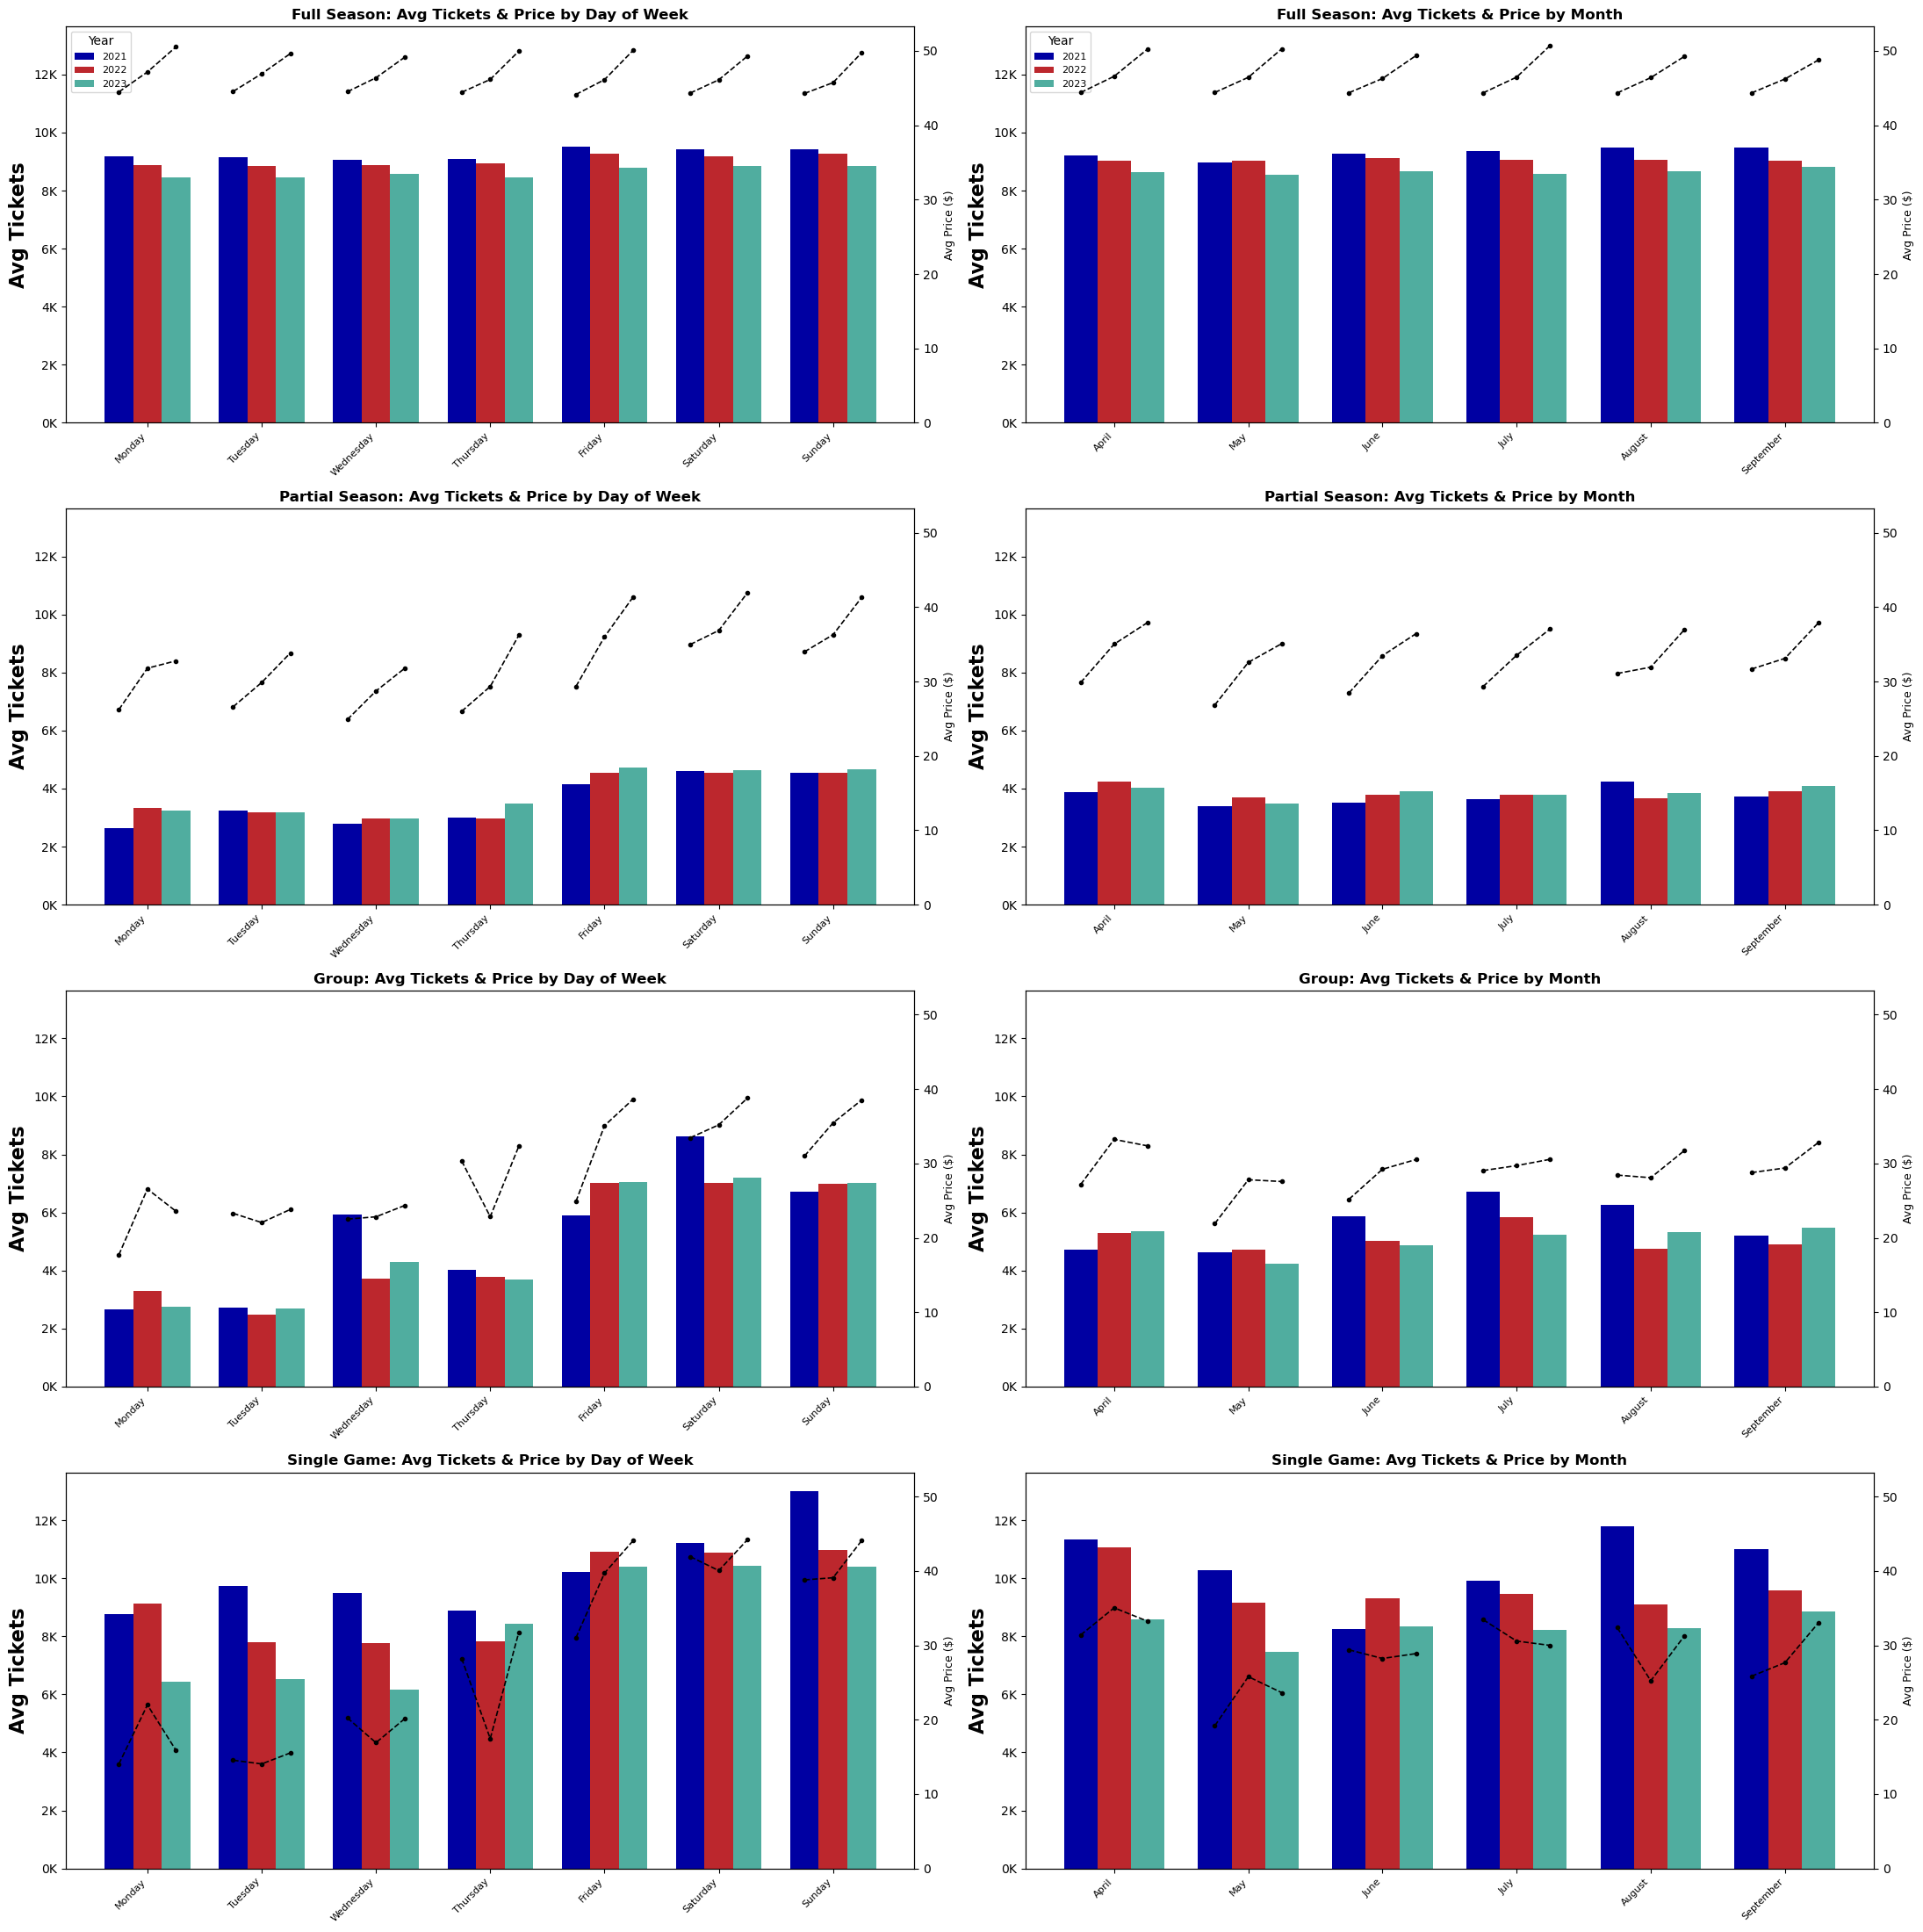

In [6]:
segments = {
    'Full Season': ('Full Season Tickets (#)', 'Full Season Avg Price ($)'),
    'Partial Season': ('Partial Season Tickets (#)', 'Partial Season Avg Price ($)'),
    'Group': ('Group Tickets (#)', 'Group Avg Price ($)'),
    'Single Game': ('Single Game Tickets (#)', 'Single Game Avg Price ($)')
}

# First pass: find shared max for tickets and price across ALL segments/cuts
max_tickets = 0
max_price = 0
for seg_name, (ticket_col, price_col) in segments.items():
    for group_col, order in [('Day of Week', DOW_ORDER), ('Month', MONTH_ORDER)]:
        t_pivot = full.groupby(['Year', group_col])[ticket_col].mean().unstack().reindex(columns=order)
        p_pivot = full.groupby(['Year', group_col])[price_col].mean().unstack().reindex(columns=order)
        max_tickets = max(max_tickets, t_pivot.max().max())
        max_price = max(max_price, p_pivot.max().max())

fig, axes = plt.subplots(4, 2, figsize=(FIGSIZE[0], FIGSIZE[1]*2.6))

for row, (seg_name, (ticket_col, price_col)) in enumerate(segments.items()):
    # LEFT: by Day of Week
    ax = axes[row, 0]
    pivot = full.groupby(['Year', 'Day of Week'])[ticket_col].mean().unstack().reindex(columns=DOW_ORDER)
    price_pivot = full.groupby(['Year', 'Day of Week'])[price_col].mean().unstack().reindex(columns=DOW_ORDER)
    x = range(len(DOW_ORDER))
    for i, (year, color) in enumerate(YEAR_COLORS.items()):
        vals = pivot.loc[year].fillna(0) if year in pivot.index else pd.Series(0, index=DOW_ORDER)
        ax.bar([xi + i * BAR_WIDTH for xi in x], vals, width=BAR_WIDTH, color=color, label=str(year))
    ax.set_title(f'{seg_name}: Avg Tickets & Price by Day of Week', fontsize=12, fontweight='bold')
    ax.set_xticks([xi + BAR_WIDTH for xi in x])
    ax.set_xticklabels(DOW_ORDER, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Avg Tickets', **LABEL_STYLE)
    ax.set_ylim(0, max_tickets * 1.05)
    ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
    if row == 0:
        ax.legend(title='Year', loc='upper left', fontsize=8)

    ax_price = ax.twinx()
    for xi in x:
        x_points = [xi + i * BAR_WIDTH for i in range(len(YEARS))]
        y_points = [price_pivot.loc[year].iloc[xi] if year in price_pivot.index else None for year in YEARS]
        ax_price.plot(x_points, y_points, color='black', marker='o', linewidth=1.2, markersize=3, linestyle='dashed')
    ax_price.set_ylabel('Avg Price ($)', fontsize=9)
    ax_price.set_ylim(0, max_price * 1.05)

    # RIGHT: by Month
    ax2 = axes[row, 1]
    pivot_m = full.groupby(['Year', 'Month'])[ticket_col].mean().unstack().reindex(columns=MONTH_ORDER)
    price_pivot_m = full.groupby(['Year', 'Month'])[price_col].mean().unstack().reindex(columns=MONTH_ORDER)
    xm = range(len(MONTH_ORDER))
    for i, (year, color) in enumerate(YEAR_COLORS.items()):
        vals = pivot_m.loc[year].fillna(0) if year in pivot_m.index else pd.Series(0, index=MONTH_ORDER)
        ax2.bar([xi + i * BAR_WIDTH for xi in xm], vals, width=BAR_WIDTH, color=color, label=str(year))
    ax2.set_title(f'{seg_name}: Avg Tickets & Price by Month', fontsize=12, fontweight='bold')
    ax2.set_xticks([xi + BAR_WIDTH for xi in xm])
    ax2.set_xticklabels(MONTH_ORDER, rotation=45, ha='right', fontsize=8)
    ax2.set_ylabel('Avg Tickets', **LABEL_STYLE)
    ax2.set_ylim(0, max_tickets * 1.05)
    ax2.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
    if row == 0:
        ax2.legend(title='Year', loc='upper left', fontsize=8)

    ax_price2 = ax2.twinx()
    for xi in xm:
        x_points = [xi + i * BAR_WIDTH for i in range(len(YEARS))]
        y_points = [price_pivot_m.loc[year].iloc[xi] if year in price_pivot_m.index else None for year in YEARS]
        ax_price2.plot(x_points, y_points, color='black', marker='o', linewidth=1.2, markersize=3, linestyle='dashed')
    ax_price2.set_ylabel('Avg Price ($)', fontsize=9)
    ax_price2.set_ylim(0, max_price * 1.05)

plt.tight_layout()
plt.show()

**Key Findings:**
- Outside of Full Season, nearly every segment and cut, price does not seem to be the cause of ticket decline. Partial Season is the clearest case, as price rose substantially on all nights while volume grew anyway, and Group/Single Game show no consistent relationship either
- Full Season has seen the highest average increase in price and also a consistent YoY decrease in tickets. This could be interesting to look into the difference between price increase and ticket decrease
- Group's Saturday decline is visible here too (tallest 2021 bar of any day, dropping in both 2022 and 2023), alongside Friday's continued strength - consistent with the ranked findings from the summary table
- Single Game still shows the clearest, most consistent YoY ticket decline of any segment across both day of week and month, while its price moves with no clear pattern tied to the decline.  We see the biggest hits are on Weekday/Sunday Games

# Quick dive into No-Show Rates to see if there is correlation with anything we have found

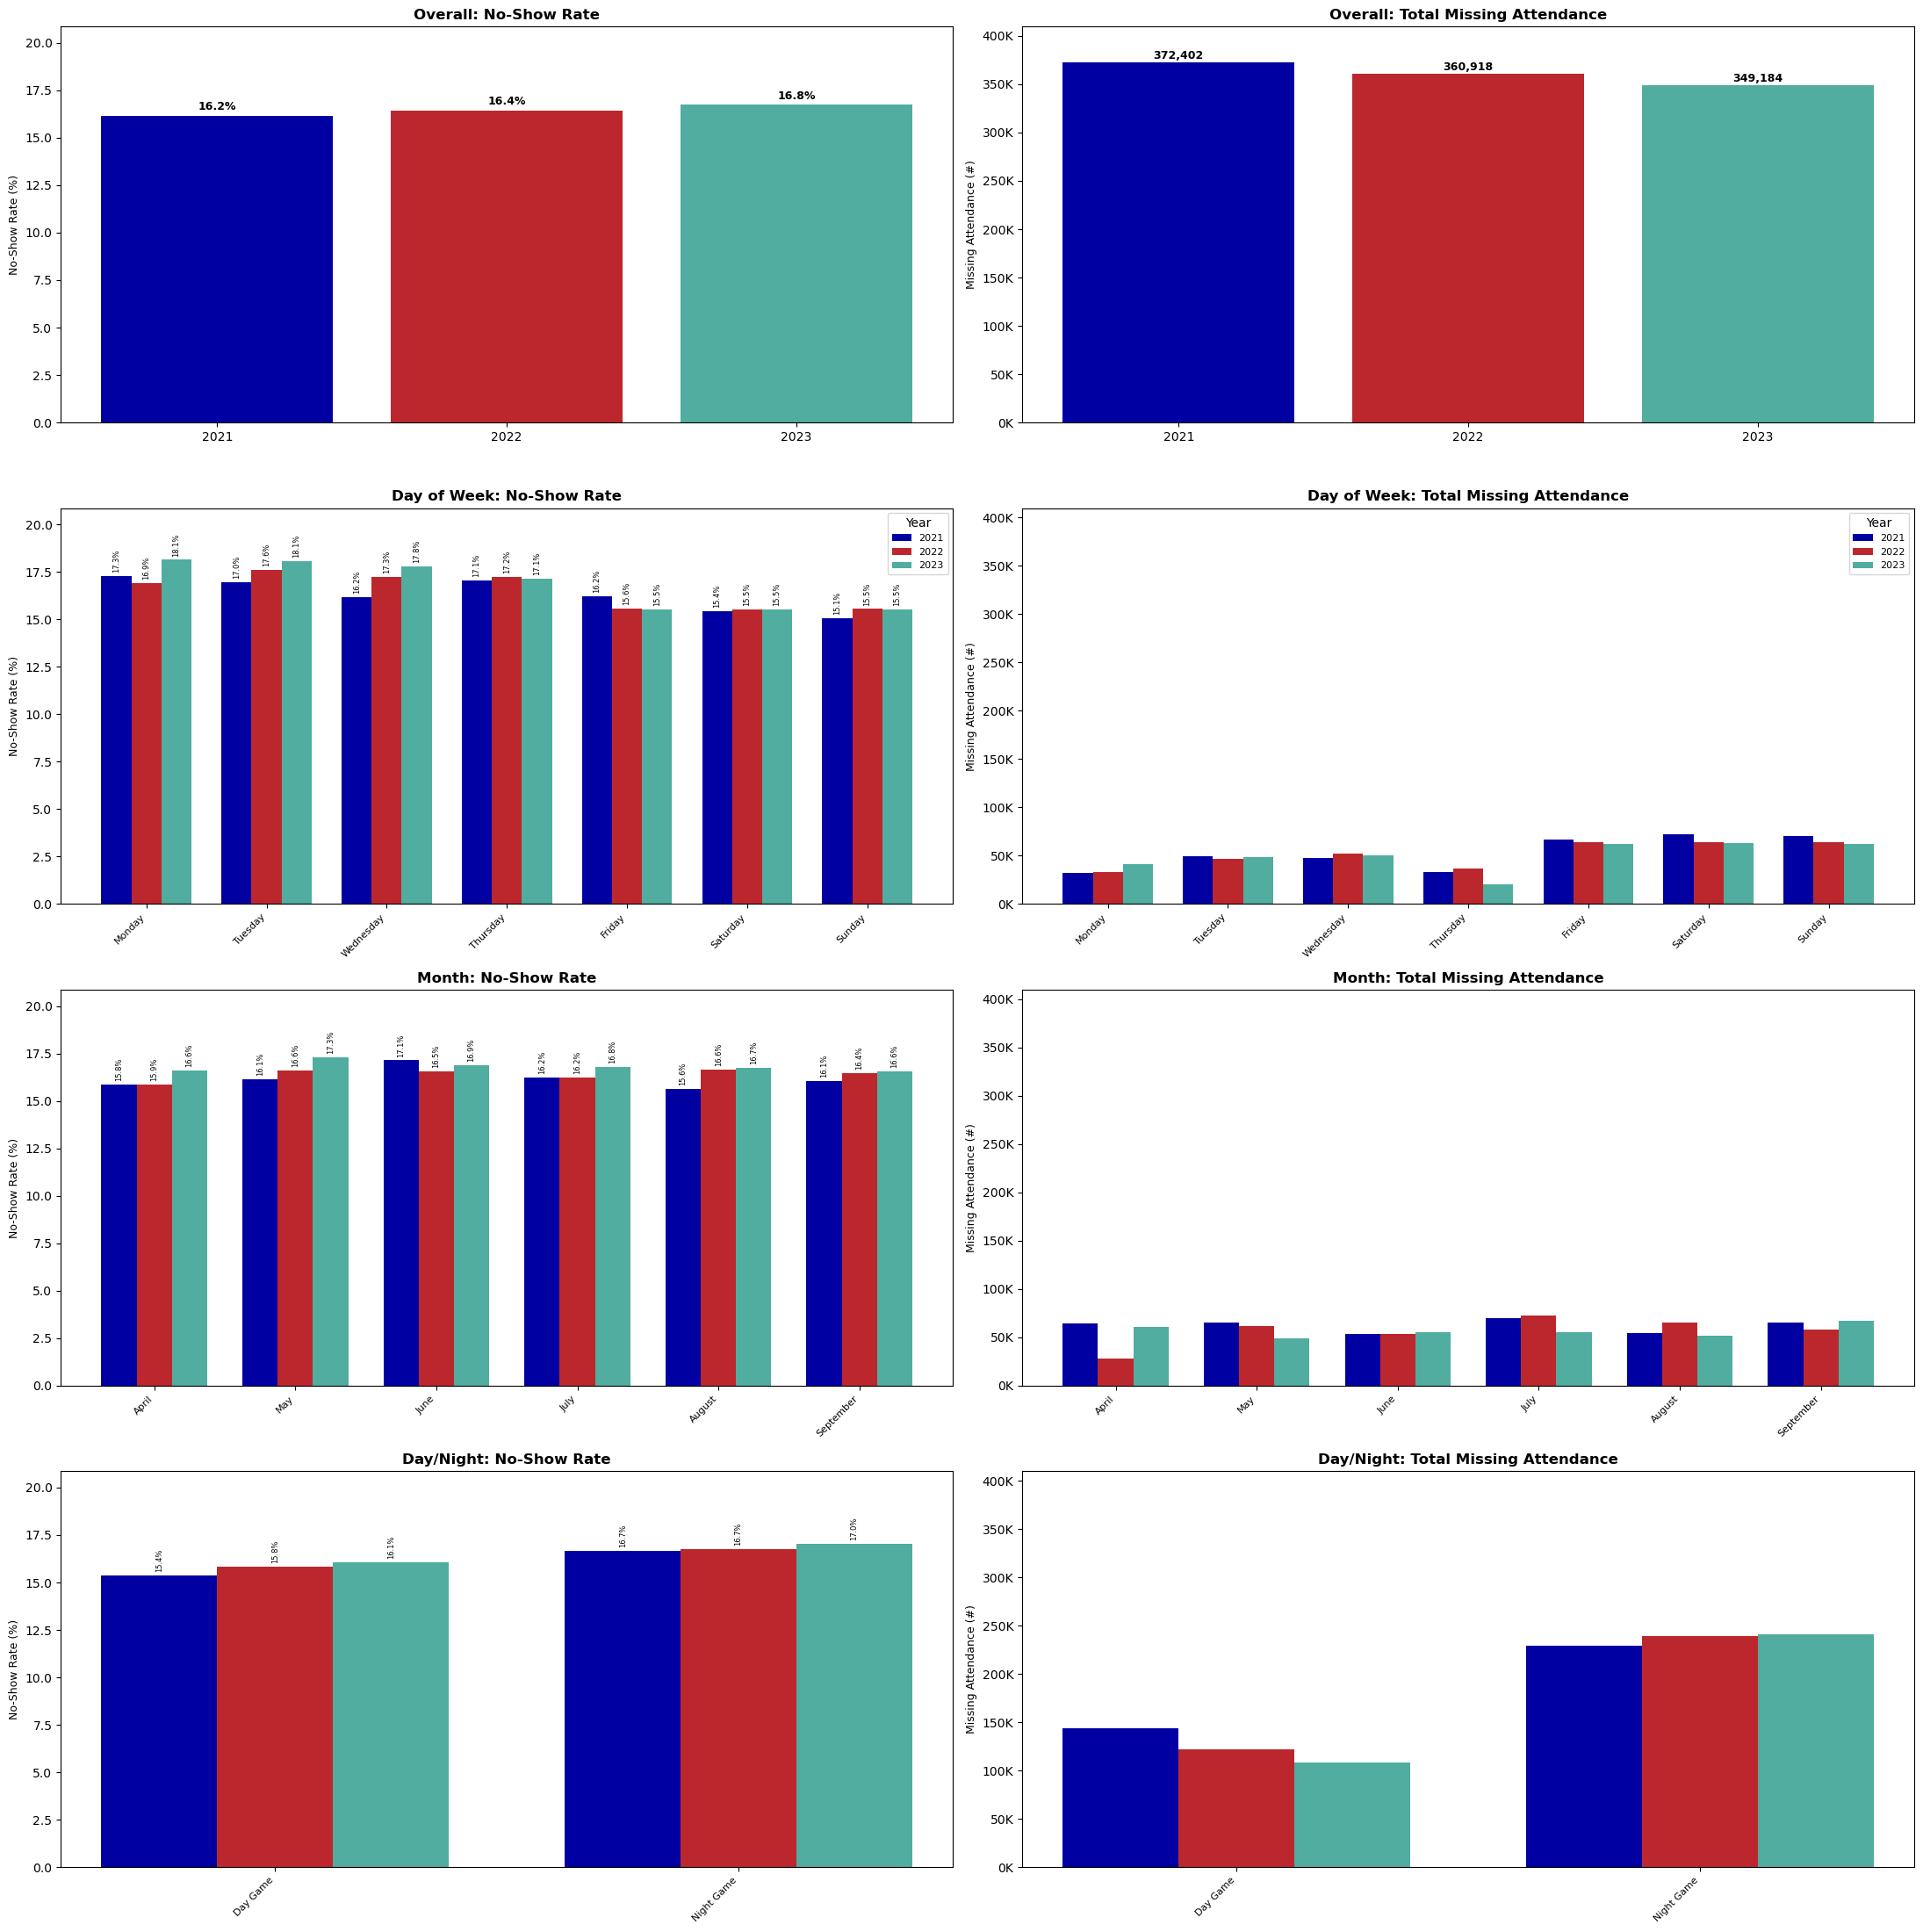

In [9]:
full['Missing People (#)'] = full['Total Tickets (#)'] - full['Actual Attendance (#)']

cuts = [
    ('Overall', None, [str(y) for y in YEARS]),
    ('Day of Week', 'Day of Week', DOW_ORDER),
    ('Month', 'Month', MONTH_ORDER),
    ('Day/Night', 'Day/Night', DAYNIGHT_ORDER),
]
# ...rest of the cell unchanged

# First pass: find shared max for rate column and missing-attendance column across all 4 rows
max_rate = 0
max_missing = 0
for label, group_col, order in cuts:
    if group_col is None:
        max_rate = max(max_rate, (full.groupby('Year')['No-Show Rate'].mean() * 100).max())
        max_missing = max(max_missing, full.groupby('Year')['Missing People (#)'].sum().max())
    else:
        rate_pivot = full.groupby(['Year', group_col])['No-Show Rate'].mean().unstack().reindex(columns=order) * 100
        missing_pivot = full.groupby(['Year', group_col])['Missing People (#)'].sum().unstack().reindex(columns=order)
        max_rate = max(max_rate, rate_pivot.max().max())
        max_missing = max(max_missing, missing_pivot.max().max())

fig, axes = plt.subplots(4, 2, figsize=(FIGSIZE[0], FIGSIZE[1]*2.6))

for row, (label, group_col, order) in enumerate(cuts):
    ax = axes[row, 0]
    ax2 = axes[row, 1]

    if group_col is None:
        rate_vals = full.groupby('Year')['No-Show Rate'].mean().reindex(YEARS) * 100
        ax.bar([str(y) for y in YEARS], rate_vals, color=list(YEAR_COLORS.values()))
        for i, v in enumerate(rate_vals):
            ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

        missing_vals = full.groupby('Year')['Missing People (#)'].sum().reindex(YEARS)
        ax2.bar([str(y) for y in YEARS], missing_vals, color=list(YEAR_COLORS.values()))
        for i, v in enumerate(missing_vals):
            ax2.text(i, v + max_missing*0.01, f'{v:,.0f}', ha='center', fontweight='bold', fontsize=9)
    else:
        x = range(len(order))
        rate_pivot = full.groupby(['Year', group_col])['No-Show Rate'].mean().unstack().reindex(columns=order) * 100
        for i, year in enumerate(YEARS):
            vals = rate_pivot.loc[year].fillna(0) if year in rate_pivot.index else pd.Series(0, index=order)
            bars = ax.bar([xi + i * BAR_WIDTH for xi in x], vals, width=BAR_WIDTH, color=YEAR_COLORS[year], label=str(year))
            for bar, v in zip(bars, vals):
                if v > 0:
                    ax.text(bar.get_x() + bar.get_width()/2, v + max_rate*0.01, f'{v:.1f}%',
                             ha='center', va='bottom', fontsize=6, rotation=90)
        ax.set_xticks([xi + BAR_WIDTH for xi in x])
        ax.set_xticklabels(order, rotation=45, ha='right', fontsize=8)
        if row == 1:
            ax.legend(title='Year', loc='upper right', fontsize=8)

        missing_pivot = full.groupby(['Year', group_col])['Missing People (#)'].sum().unstack().reindex(columns=order)
        for i, year in enumerate(YEARS):
            vals = missing_pivot.loc[year].fillna(0) if year in missing_pivot.index else pd.Series(0, index=order)
            ax2.bar([xi + i * BAR_WIDTH for xi in x], vals, width=BAR_WIDTH, color=YEAR_COLORS[year], label=str(year))
        ax2.set_xticks([xi + BAR_WIDTH for xi in x])
        ax2.set_xticklabels(order, rotation=45, ha='right', fontsize=8)
        if row == 1:
            ax2.legend(title='Year', loc='upper right', fontsize=8)

    ax.set_title(f'{label}: No-Show Rate', fontsize=12, fontweight='bold')
    ax.set_ylabel('No-Show Rate (%)', fontsize=9)
    ax.set_ylim(0, max_rate * 1.15)

    ax2.set_title(f'{label}: Total Missing Attendance', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Missing Attendance (#)', fontsize=9)
    ax2.set_ylim(0, max_missing * 1.1)
    ax2.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

plt.tight_layout()
plt.show()

**Key Findings:**
- **No-show % is increasing across almost every segment but it is largely a weekday story. Weekday average rose every year (16.8%->17.9%) while weekend stayed essentially flat (15.6%->15.5%). This is where we see the highest increases as well as rates.**
- **Note:** We do not know No-Show Rate by Ticket Type
  
**Additional Notes:**
- Worth noting that Thursday decreases despite flat rate increases.  There may be a shift in games overtime we need to understand

# **Final Initial Thoughts**

- Tickets are down every year while revenue is up, driven by price. Price increases are masking a real attendance problem
- **Single Game is the main driver of the ticket decline and the segment we need to dig into most**
- Full Season has the highest price increase **AND** a consistent YoY ticket decrease which may be worth understanding if/how these are connected
- **Partial Season looks like our most reliable segment with consistent tickets YoY and revenue keeps climbing**
- Group's decline looks different as 2021 tracks with 2022/2023 for about half the season then pulls ahead in the back half. Something may have changed in 2021 that didn't repeat. Also seeing a real Saturday-specific decline for Group worth checking
- **Outside of Full Season, price doesn't look like the driver anywhere. Partial Season proves this most clearly with the price up, volume up anyway**
- Single Game's biggest hits are on Weekday and Sunday games specifically
- **No-Show Rates Support the overall weekday problem story**

**Next Steps: Analysis Deep Dives** (Based on potential size of ticket opportunity)
1. **Single Game (Weekdays & Sunday)** - the dominant driver, gets the most depth
2. **Full Season (price/attendance relationship)** - second-largest
3. **Partial Season (what's working/what can we learn)** - highest-leverage lever